In [133]:
# importing cfd_jacobian module
# remember to pip install pyau3d in conda
import numpy as np
from pyau3d.utils import PltFileUtils, GrpFileUtils, UnkFileUtils
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import pandas as pd
from cfd_jacobians import (
    compute_viscous_jacobian,
    compute_central_jacobian,
    compute_roe_jacobian,
)
# from cfd_jacobians import compute_central_jacobian
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import eigs

%matplotlib widget

In [134]:
# define required function

def get_exact_inviscid_jacobian_rhoE(U, nx, ny, nz, gamma):
    """
    Computes the exact analytical 3D Euler flux Jacobian matrix 
    where the conservative state vector is U = [rho, rhou, rhov, rhow, rhoE].
    """
    rho  = U[0]
    rhou = U[1]
    rhov = U[2]
    rhow = U[3]
    rhoE = U[4]
    
    u = rhou / rho
    v = rhov / rho
    w = rhow / rho
    E = rhoE / rho
    
    q2 = u**2 + v**2 + w**2

    phi = 0.5 * (gamma - 1) * q2
    V_n = u * nx + v * ny + w * nz
    a1 = gamma * E - phi
    a2 = gamma - 1
    a3 = gamma - 3
    
    A = np.zeros((5, 5))
    
    # Row 0: Continuity (rho)
    A[0, 0] = 0.0
    A[0, 1] = nx
    A[0, 2] = ny
    A[0, 3] = nz
    A[0, 4] = 0.0
    
    # Row 1: X-Momentum (rhou)
    A[1, 0] = nx * phi - u * V_n
    A[1, 1] = V_n - a3 * nx * u
    A[1, 2] = ny * u - a2 * nx * v
    A[1, 3] = nz * u - a2 * nx * w
    A[1, 4] = a2 * nx
    
    # Row 2: Y-Momentum (rhov)
    A[2, 0] = ny * phi - v * V_n
    A[2, 1] = nx * v - a2 * ny * u
    A[2, 2] = V_n - a3 * ny * v
    A[2, 3] = nz * v - a2 * ny * w
    A[2, 4] = a2 * ny
    
    # Row 3: Z-Momentum (rhow)
    A[3, 0] = nz * phi - w * V_n
    A[3, 1] = nx * w - a2 * nz * u
    A[3, 2] = ny * w - a2 * nz * v
    A[3, 3] = V_n - a3 * nz * w
    A[3, 4] = a2 * nz
    
    # Row 4: Energy (rhoE) -> Notice the changes here due to d(rhoE) mapping
    A[4, 0] = V_n * (phi - a1)
    A[4, 1] = nx * a1 - a2 * u * V_n
    A[4, 2] = ny * a1 - a2 * v * V_n
    A[4, 3] = nz * a1 - a2 * w * V_n
    A[4, 4] = gamma * V_n
    
    return A

def read_direct_jacobian(filename):
    """
    Reads jacobian.txt and reshapes it to (N, 5, 5)
    Assumes first column is index.
    """
    J_raw = pd.read_csv(
        filename,
        delim_whitespace=True,
        header=None
    ).to_numpy()

    # Drop index column and reshape
    J = J_raw[:, 1:].reshape(-1, 5, 5, order="F")
    return J

def specific_energy(rho, p, ux, uy, uz, gamma=1.4):
    return p / ((gamma - 1.0) * rho) + 0.5 * (ux**2 + uy**2 + uz**2)

def conservative_variables(rst, GAMMA):
    """Return conservative variables U on the surface."""
    E = specific_energy(rst.rho, rst.p, rst.ux, rst.uy, rst.uz, GAMMA)

    U = np.column_stack((
        rst.rho,
        rst.rho * rst.ux,
        rst.rho * rst.uy,
        rst.rho * rst.uz,
        rst.rho * E
    ))
    return U

def convert_Aij_to_Nij(Aij):
    A = np.linalg.norm(Aij)

    # Safety check for zero-area/degenerate faces to avoid division by zero
    if A < 1e-14:
        return np.zeros(3), 0.0
        
    nij = Aij / A
    return nij, A

def run_verification():
    # Concrete uniform flow example parameters
    Ui_val = np.array([1.0, 1.2, 0.0, 0.0, 2.5])
    Uj_val = np.array([1.0, 1.2, 0.0, 0.0, 2.5])
    nx, ny, nz = 1.0, 0.0, 0.0
    gamma = 1.4

    # 1. Compute your code's numerical parts
    Ji, Jj = compute_central_jacobian(Ui_val, Uj_val, nx, ny, nz, gamma)
    
    print("--- 1. Dimensions and Structure Check ---")
    print(f"Ji Shape: {Ji.shape} (Expected: (5, 5))")
    print(f"Jj Shape: {Jj.shape} (Expected: (5, 5))")
    
    # Check for NaN and Inf
    assert np.isfinite(Ji).all(), "Error: Ji contains NaNs or Inf values!"
    assert np.isfinite(Jj).all(), "Error: Jj contains NaNs or Inf values!"
    print("Structure check: PASSED (Dimensions match, all entries are finite numbers)")
    
    print("\n--- 2. Computed Numerical Matrices ---")
    np.set_printoptions(precision=4, suppress=True)
    print("Matrix Ji (dRi/dUi):")
    print(Ji)
    print("\nMatrix Jj (dRi/dUj):")
    print(Jj)
    
    # 2. Check mathematical property: Symmetry under uniform flow
    print("\n--- 3. Mathematical Consistency Verifications ---")
    symmetry_passed = np.allclose(Ji, Jj, rtol=1e-12, atol=1e-12)
    print(f"Symmetry Check (Ji == Jj): {'PASSED' if symmetry_passed else 'FAILED'}")
    
    # 3. Check mathematical property: Sum equals analytical flux Jacobian
    A_exact = get_exact_inviscid_jacobian(Ui_val, nx, ny, nz, gamma)
    J_sum = Ji + Jj
    
    consistency_passed = np.allclose(J_sum, A_exact, rtol=1e-12, atol=1e-12)
    print(f"Linear Flux Consistency Check (Ji + Jj == A_exact): {'PASSED' if consistency_passed else 'FAILED'}")
    
    # Run assertions
    assert symmetry_passed, "Symmetry verification failed."
    assert consistency_passed, "Analytical flux consistency validation failed."
    print("\n[SUCCESS] Your compute_central_jacobian function is perfectly accurate!")

In [135]:
# Load necessary files

# define Reynolds number
Re = 50

# dir = "/home/ahf25/CFD_2d_cylinder_all/Steady/2d_cylinder_12625_Re50" # change to inviscid jacobian
dir = f"../2d_cylinder_12625_Re{50}"

pltfile = PltFileUtils(f"{dir}/cylinder.plt") # redefine file path later
rstfile = UnkFileUtils(f"{dir}/cylinder.rst", extend=False) # read file at iteraton = 101

# read fort file - [i nodes, j nodes, Ax, Ay, Az. cell volume]
fortfile = pd.read_csv(f"{dir}/fort.864",delim_whitespace=True, header=None)
fortfile = fortfile.to_numpy()

# Compute flow primitives 
rstfile._primitive()

# Extract list of coordinates (N,3)
coord = pltfile.coord

J_print = read_direct_jacobian(f"{dir}/jacobian.txt")

C:\Users\User\AppData\Local\Temp\ipykernel_25976\3341131308.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fortfile = pd.read_csv(f"{dir}/fort.864",delim_whitespace=True, header=None)
C:\Users\User\AppData\Local\Temp\ipykernel_25976\3373744444.py:71: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  J_raw = pd.read_csv(


In [136]:
# define gamma - specific heat ratio
gamma = 1.4

# define laminar dynamic viscosity
mu = 1.8e-5
# define turbulent dynamic viscosity 
mu_t = 0 # zero in this laminar case

# define laminar prandtl number
Pr = 0.72
# define turbulent prandtl number
Pr_t = 0.9


U = conservative_variables(rstfile, gamma) # compute conservative variables for n nodes (n, 5) array
i_nodes = fortfile[:,0].astype("i")
j_nodes = fortfile[:,1].astype("i")
A = fortfile[:,2:5]
V = fortfile[:,5]


In [137]:
# testing
# compute nx, ny, nz

indexi = 0

# mimic outer loop
node_i= indexi + 1
U_i = U[indexi,:] # U_i conservative variable vector for node i 
neighbours_j = j_nodes[i_nodes == node_i] # neighbours node j 
U_j_all = U[neighbours_j - 1 ,:] # U conservative variable vectors for all neighbouring nodes j (number_of_neighbours , 5)
V_i = V[indexi] # cell volume for node i
A_ij_all = A[i_nodes == node_i, :] # Aij area normal vector for all neighbouring nodes j (number_of_neighbours , 3)

# mimin inner loop
indexj = 0
node_j = neighbours_j[indexj] # extract the neighbouring node j 

U_j = U_j_all[indexj]
A_ij = A_ij_all[indexj,:]

# compute nij - 3D array, A =  area magnitude
n_ij, Area = convert_Aij_to_Nij(A_ij)

rho_i = U_i[0]
rho_j = U_j[0]
rho_ij = (rho_i + rho_j)/2 

x_i = coord[node_i-1]
x_j = coord[node_j-1]

# jacobian_fn(Ui_val, Uj_val, nx_val, ny_val, nz_val, gamma_val)
J_invisc_ii_c, J_invisc_ij_c = compute_central_jacobian(U_i, U_j, n_ij[0], n_ij[1], n_ij[2], gamma)


In [138]:
# define number of nodes
N = np.shape(U)[0]
# add viscous part or not ?
viscous =  True

# initialise the jacobian matrix as a  List of Lists sparse matrix (lil_matrix) with size of (5*N, 5*N)
J_matrix = lil_matrix((5*N, 5*N))

for indexi in range(N):
# for indexi in range(1):
    node_i= indexi + 1 # define node i 

    U_i = U[indexi,:] # U_i conservative variable vector for node i 
    neighbours_j = j_nodes[i_nodes == node_i] # neighbours node j 
    U_j_all = U[neighbours_j - 1 ,:] # U conservative variable vectors for all neighbouring nodes j (number_of_neighbours , 5)
    A_ij_all = A[i_nodes == node_i, :] # Aij area normal vector for all neighbouring nodes j (number_of_neighbours , 3)
    # print(f"for node {node_i}: ")
    # print("U at node i: ", U_i)
    # print("Aij(s): ",A_ij_all)
    # print("corresponding Vi: ", V_i)

    for indexj in range(len(neighbours_j)):
        node_j = neighbours_j[indexj] # extract the neighbouring node j 

        U_j = U_j_all[indexj]
        A_ij = A_ij_all[indexj,:]

        n_ij, Area = convert_Aij_to_Nij(A_ij)
        
        # viscous part 

        rho_i = U_i[0]
        rho_j = U_j[0]
        rho_ij = (rho_i + rho_j)/2 

        x_i = coord[node_i-1]
        x_j = coord[node_j-1]

        # viscous part compute, by default mu_t = 0, Pr_t = 0.9
        if viscous == True:
            lam, J_visc = compute_viscous_jacobian(
            mu=mu, Pr=Pr, gamma=gamma, rho=rho_ij,
            xi=x_i, xj=x_j)
        else:
            J_visc = np.zeros((5,5))

        # inviscid jacobian
        J_invisc_ii_c, J_invisc_ij_c = compute_central_jacobian(U_i, U_j, n_ij[0], n_ij[1], n_ij[2], gamma)

        # # inviscid — Roe
        # J_invisc_ii_Aij_r, J_invisc_ij_Aij_r = compute_roe_jacobian(U_i, U_j, A_ij, V_i, gamma)

        # print("corresponding node j: ", node_j)
        # print("corresponding Uj: ", U_j )
        # print("corresponding Aij: ", A_ij )
        # print(rho_i)
        # print(rho_j)

        # note that Aij is not aborbed in the formulation of J_visc (viscous part)
        J_matrix[5*(node_i-1): 5*(node_i-1)+5, 5*(node_i-1): 5*(node_i-1)+5] += J_invisc_ii_c * Area - 1 /Re * J_visc * Area
        J_matrix[5*(node_i-1): 5*(node_i-1)+5, 5*(node_j-1): 5*(node_j-1)+5] = J_invisc_ij_c * Area
        J_matrix[5*(node_j-1): 5*(node_j-1)+5, 5*(node_i-1): 5*(node_i-1)+5] += - ( J_invisc_ii_c * Area - 1 /Re * J_visc * Area )
        J_matrix[5*(node_j-1): 5*(node_j-1)+5, 5*(node_j-1): 5*(node_j-1)+5] = - J_invisc_ij_c * Area

In [139]:
# extract cylinder boundary nodes
side_coords, side_nodes, side_nodemap = pltfile.extract_surface(flag=7)
print("nodes on cylinder surface", side_nodes)

# sort out terms with large error
nodes_with_large_error = list()

for num_diagonal in range(N):
    diagonal_block_J = J_matrix[num_diagonal:num_diagonal+ 5, num_diagonal:num_diagonal+ 5].toarray()
    diagonal_block_J_print = J_print[num_diagonal]

    error = np.sqrt(np.mean((diagonal_block_J - diagonal_block_J_print) ** 2))

    if  error > 0.10:
        # print(num_diagonal + 1)
        # print(error)
        nodes_with_large_error.append(num_diagonal + 1)


nodes_with_large_error = np.array(nodes_with_large_error)
sort = nodes_with_large_error[nodes_with_large_error > 2387]
print("nodes with large error: ",sort)
print("proportion of terms with large error: ", len(nodes_with_large_error)/N)

nodes on cylinder surface [10934 10936 10940 10946 10950 10959 10969 10973 10977 10984 10985 10987
 10994 10996 11002 11013 11016 11021 11026 11033 11037 11038 11039 11040
 11045 11055 11060 11062 11064 11071 11077 11078 11083 11090 11095 11096
 11104 11109 11111 11112 11114 11126 11134 11135 11139 11145 11146 11150
 11154 11160 11167 11171 11172 11182 11187 11196 11198 11204 11205 11206
 11207 11208 11214 11225 11228 11255 11261 11264 11268 11269 11271 11272
 11284 11285 11295 11305 11307 11316 11317 11323 11327 11329 11336 11341
 11345 11351 11357 11363 11365 11374 11376 11382 11397 11398 11404 11405
 11409 11414 11417 11424 11427 11434 11440 11445 11450 11455 11459 11465
 11470 11475 11479 11484 11490 11495 11499 11502 11509 11514 11520 11524
 11530 11535 11539 11542 11549 11554 11559 11564 11569 11574 11579 11584
 11587 11594 11599 11604 11609 11614 11619 11624 11629 11632 11640 11645
 11650 11654 11657 11664 11669 11672 11679 11684 11689 11692 11699 11704
 11707 11714 11719 11724 

In [140]:
# compute eigenvalues

# convert to CSR and test out eigensolver
J_matrix = J_matrix.tocsr()

# define Strohaul number obtained from unsteady CFD
St = 0.1469

# angular frequency (rad/s)
wr = St * 2 * np.pi

# growth rate
wi = 0.334

# define sigma - eigenvalues near sigma
sigma = 1j*wr + wi

# run eigs function
# Largest Real part LR
vals, vecs = eigs(J_matrix, k=20, sigma=sigma, which = "LM")

mode 1: imganiary = -0.9275000229071599, real = 0.3289585930393849
mode 2: imganiary = 0.9275000229071599, real = 0.3289585930393849
mode 3: imganiary = -0.925814184820276, real = 0.34377626102614467
mode 4: imganiary = 0.925814184820276, real = 0.34377626102614467
mode 5: imganiary = 0.9034517046331225, real = 0.33104259202175906
mode 6: imganiary = -0.9034517046331225, real = 0.33104259202175906
mode 7: imganiary = -0.947751808084083, real = 0.33315912966972866
mode 8: imganiary = 0.947751808084083, real = 0.33315912966972866
mode 9: imganiary = -0.9340002958435613, real = 0.3060288281420994
mode 10: imganiary = 0.9340002958435613, real = 0.3060288281420994
mode 11: imganiary = 0.9129577369946058, real = 0.30265930777131334
mode 12: imganiary = -0.9129577369946058, real = 0.30265930777131334
mode 13: imganiary = 0.9034389866821341, real = 0.3615906958222378
mode 14: imganiary = -0.9034389866821341, real = 0.3615906958222378
mode 15: imganiary = -0.9466741722207879, real = 0.363818626

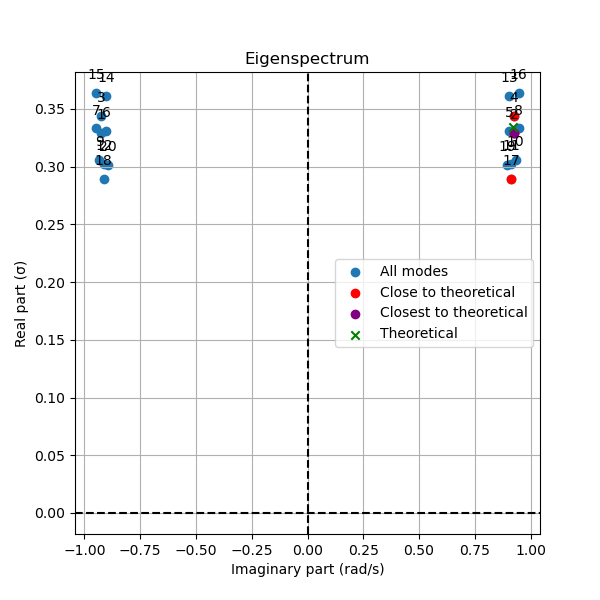

array([0.32895859, 0.32895859])

In [ ]:
# plotting the eigen specturm

real = np.real(vals)
imag = np.imag(vals)

# filter out modes that are close to wr
close_to_wr = np.abs(wr - imag) < 0.01

closest = np.argmin(np.abs(real[close_to_wr] - wi))

plt.figure(figsize=(6,6))
plt.scatter(imag, real, label = "All modes")

# plot close modes
plt.scatter(imag[close_to_wr], real[close_to_wr], color = "r",  label = "Close to theoretical")

# plot close modes
plt.scatter(imag[close_to_wr][closest], real[close_to_wr][closest], color = "purple",  label = "Closest to theoretical")

# plot theorectical mode
plt.scatter(wr, wi, marker='x', color = "g", label = "Theoretical")
# plot the number of modes on each data point as well

for i in range(len(real)):
    plt.annotate(i+1, (imag[i], real[i]), textcoords="offset points", xytext=(0,10), ha='center')
    print(f"mode {i+1}: imganiary = {imag[i]}, real = {real[i]}")

plt.legend()
plt.axvline(0, color='k', linestyle='--')
plt.axhline(0, color='k', linestyle='--')

plt.ylabel("Real part (σ)")
plt.xlabel("Imaginary part (rad/s)")
plt.title("Eigenspectrum")
plt.grid(True)
plt.show()

real == real[close_to_wr][closest]

In [ ]:
# obtaining the modeshape that is closest to the target point
k = 2
nvar = 5
# Pick the k-th eigenvector (column)
vec = vecs[:, k-1]  

# Reshape to (N, 5) — each row is one node, each column is one variable
mode = vec.reshape(N, nvar)

# Extract individual variables across all nodes
rho_mode  = mode[:, 0]   # density perturbation at all N nodes
u_mode  = mode[:, 1]   # u-velocity perturbation at all N nodes
v_mode  = mode[:, 2]   # v-velocity perturbation at all N nodes
w_mode  = mode[:, 3]   # w-velocity perturbationat all N nodes
E_mode = mode[:, 4]   # energy perturbation at all N nodes

# u_mode is complex — paper plots the real part
u_real = np.real(u_mode)          # shape (N,)

In [143]:
# Extract the side surface
side_coords, side_nodes, side_nodemap = pltfile.extract_surface(flag=3)

# note : flag = 3 is the flag on the out of plane surface, the xy plane
# flag = 4 is the bottom plane and flag = 3 is the top plane

# setting x and y bounds for the data
x_upper = 20
x_lower = -5
y_upper = 5
y_lower = -5

# use some utilities from GrpFileUtils
tmp_grp = GrpFileUtils('tmp', 0, 
                       read=False,
                       coord=side_coords, 
                       nodes=side_nodes)
tmp_grp.root_nodemap = side_nodemap 

# Filter points based on x and y coordinate bounds 
node_filter = (side_coords[:, 0] > x_lower) & (side_coords[:, 0] < x_upper) & (side_coords[:, 1] > y_lower) & (side_coords[:, 1] < y_upper )
tmp_grp.node_filter = node_filter

# Extract triangle nodemap
tri_nodemap = tmp_grp.get_tri_nodemap() 

# saving the x and y coordinates to grp_x and grp_y

grp_x = tmp_grp.coords[:, 0]
grp_y = tmp_grp.coords[:, 1]
# Construct a matplotlib Triangulation (defines our mesh for plotting)
tri = Triangulation(grp_x, grp_y, triangles=tri_nodemap)



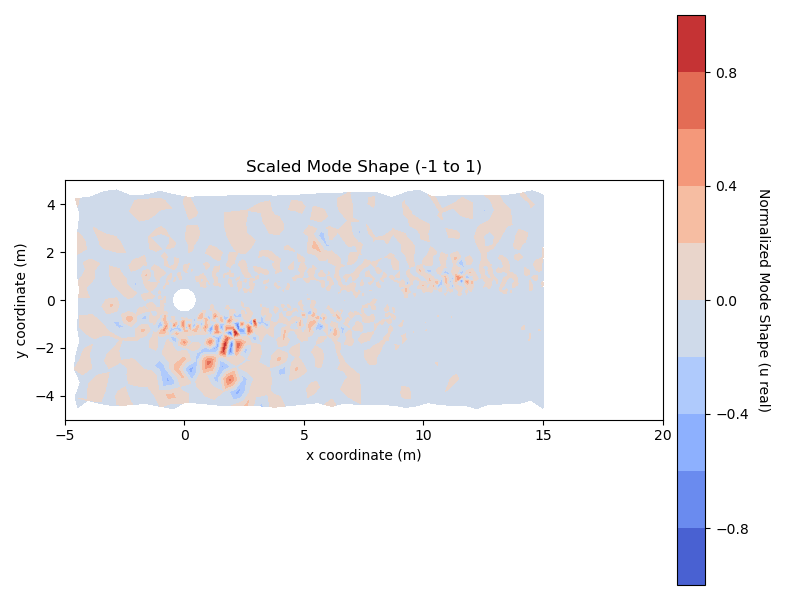

In [144]:
# 1. Extract your raw contour data array
z_raw = u_real[side_nodes][node_filter]

# 2. Apply the min-max scaling to shift the range to [-1, 1]
z_min = np.min(z_raw)
z_max = np.max(z_raw)

# Prevent division by zero if the mode shape array is completely uniform
if np.abs(z_max - z_min) > 1e-12:
    z_scaled = 2.0 * (z_raw - z_min) / (z_max - z_min) - 1.0
else:
    z_scaled = np.zeros_like(z_raw)

# 3. Plot the density map using the scaled values
fig, ax = plt.subplots(figsize=(8, 6))

# Pass z_scaled into tricontourf
contour = ax.tricontourf(tri, z_scaled, levels=11, cmap="coolwarm")

# Add the colorbar; its bounds will now naturally lock between -1.0 and 1.0
cbar = fig.colorbar(contour, ax=ax, pad=0.02)
cbar.set_label('Normalized Mode Shape (u real)', rotation=270, labelpad=15)

ax.set_title("Scaled Mode Shape (-1 to 1)")
ax.set_xlabel("x coordinate (m)")
ax.set_ylabel("y coordinate (m)")
ax.set_aspect('equal', 'box') 

ax.set_xlim(x_lower, x_upper)
ax.set_ylim(y_lower, y_upper)

plt.tight_layout()
plt.show()

In [145]:
# testing
# --- shared test data ---
gamma = 1.4
rho_i, rho_j = 1.0, 1.1
Ui  = np.array([rho_i, rho_i*0.5, rho_i*0.2, 0.0, rho_i*2.5])
Uj  = np.array([rho_j, rho_j*0.4, rho_j*0.1, 0.0, rho_j*2.3])
Aij = np.array([1.0, 0.0, 0.0])
Vi  = 0.1

# viscous
lam, J_visc = compute_viscous_jacobian(
    mu=1.8e-5, Pr=0.72, gamma=gamma, rho=1.05,
    xi=[0.0, 0.0, 0.0], xj=[0.1, 0.0, 0.0]
)

# inviscid — central
dRi_dUi_c, dRi_dUj_c = compute_central_jacobian(Ui, Uj, Aij, Vi, gamma)

# inviscid — Roe
dRi_dUi_r, dRi_dUj_r = compute_roe_jacobian(Ui, Uj, Aij, Vi, gamma)

TypeError: _build.<locals>.jacobian_fn() missing 1 required positional argument: 'gamma_val'